# Named Entity Recognition (NER) with spaCy

## Step 1: Load Data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Use sklearn for dataset
from sklearn.datasets import fetch_20newsgroups

# Import spaCy for NER
import spacy
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load a subset of the 20 newsgroups dataset (3 categories)
categories = [
    'rec.sport.baseball',
    'talk.politics.guns',
    'sci.space'
]

# Fetch the dataset, removing headers/footers/quotes for cleaner text
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Extract documents and create labels mapping
documents = newsgroups.data
category_names = newsgroups.target_names

# Check results
print(f"Number of documents: {len(documents)}")
print(f"Categories: {category_names}")
print(f"\nSample document:\n{documents[0][:250]}...")

Number of documents: 2891
Categories: ['rec.sport.baseball', 'sci.space', 'talk.politics.guns']

Sample document:

This activity is regularly reported in Ron's interesting posts. Could
someone explain what the Command Loss Timer is?

Thanks, Alan...


## Step 2: Load spaCy Model

In [3]:
# Load spaCy's pre-trained English model for NER
# This model has been trained on OntoNotes 5 and can recognize multiple entity types
# If not installed, run: python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

# Define entity types to focus on for this demo
# PERSON: People, including fictional characters
# DATE: Absolute or relative dates or periods
# LAW: Named laws, legal documents, or legal references

ENTITY_TYPES = ['PERSON', 'DATE', 'LAW']

## Step 3: Perform Named Entity Recognition

In [4]:
def extract_entities(
    documents: list,
    nlp: spacy.language.Language,
    max_docs: int = 100
) -> pd.DataFrame:
    """
    Extract named entities from a list of documents using spaCy.
    Process documents through the SpaCy NER pipeline.
    Extract all recognized entities with types and source document info.
    
    Parameters:
    documents (list): List of text documents to process.
    nlp (spacy.language.Language): Loaded spaCy language model with NER pipeline.
    max_docs (int): Maximum number of documents to process (default: 100).
    
    Returns:
    pd.DataFrame: DataFrame containing columns for entity text, type, and document index.
    """
    entities = []
    
    # Process a subset of documents to keep runtime reasonable
    for doc_idx, doc_text in enumerate(documents[:max_docs]):
        # Apply spaCy NER pipeline to the document
        doc = nlp(doc_text)
        
        # Extract each entity found in the document
        for ent in doc.ents:
            entities.append({
                'text': ent.text,
                'label': ent.label_,
                'doc_idx': doc_idx
            })
    
    # Convert to DataFrame for easier analysis
    return pd.DataFrame(entities)

# Extract entities from documents
print("Extracting entities from documents...")
entities_df = extract_entities(documents, nlp, max_docs=1000)

# Filter to only the entity types we're focusing on
entities_df = entities_df[entities_df['label'].isin(ENTITY_TYPES)]

# Check results
print(f"\nTotal entities extracted (PERSON, DATE, LAW): {len(entities_df)}")
print(f"\nExample entities extracted:")
print(entities_df.head(10))

Extracting entities from documents...

Total entities extracted (PERSON, DATE, LAW): 4305

Example entities extracted:
             text   label  doc_idx
0             Ron  PERSON        0
1            Alan  PERSON        0
2   Ali AbuTaha's  PERSON        1
6           Roger  PERSON        2
8            1988    DATE        2
9       Bob Errey  PERSON        2
10  Wayne Gretzky  PERSON        2
11          Errey  PERSON        2
13          Wayne  PERSON        2
15        Gretzky  PERSON        2


## Step 4: Examine Entity Distributions

In [5]:
def display_entity_stats(
    entities_df: pd.DataFrame,
    n_top: int = 10
) -> None:
    """
    Display statistics about extracted entities including counts and examples.
    
    This function analyzes the entity DataFrame to show the distribution of
    entity types and provides example entities for each type as a comma-separated
    list to help understand what the NER model identified.
    
    Parameters:
    entities_df (pd.DataFrame): DataFrame containing extracted entities with 'text' and 'label' columns.
    n_top (int): Number of top examples to display per entity type (default: 10).
    
    Returns:
    None: Prints entity statistics to stdout.
    """
    # Count entities by type
    entity_counts = entities_df['label'].value_counts()
    
    print("ENTITY TYPE DISTRIBUTION:")
    print(entity_counts)
    
    # Show examples for each entity type as comma-separated lists
    print(f"\nEXAMPLES BY ENTITY TYPE:")
    for label in entity_counts.index:
        # Get top entities of this type by frequency
        label_entities = entities_df[entities_df['label'] == label]['text']
        top_entities = label_entities.value_counts().head(n_top).index.tolist()
        
        # Display as comma-separated list
        print(f"{label}: {', '.join(top_entities)}")

# Display entity statistics
display_entity_stats(entities_df, n_top=10)

ENTITY TYPE DISTRIBUTION:
label
PERSON    2616
DATE      1628
LAW         61
Name: count, dtype: int64

EXAMPLES BY ENTITY TYPE:
PERSON: Moon, Clinton, Dodgers, Cooper, Dewey B. Larson, David Koresh, Jim, Cranston, Bos, Allen
DATE: today, last year, 1992, this year, 1988, yesterday, 1993, Sunday, 1990, 1991
LAW: Constitution, the Second Amendment, the Transition Experiment, Constitutional, Chapter 7, Contents, the Lorentz Transformation, the Implementation Plan, Reed, the Constitution of the US


## Step 5: Visualize and Analyze Entity Distributions

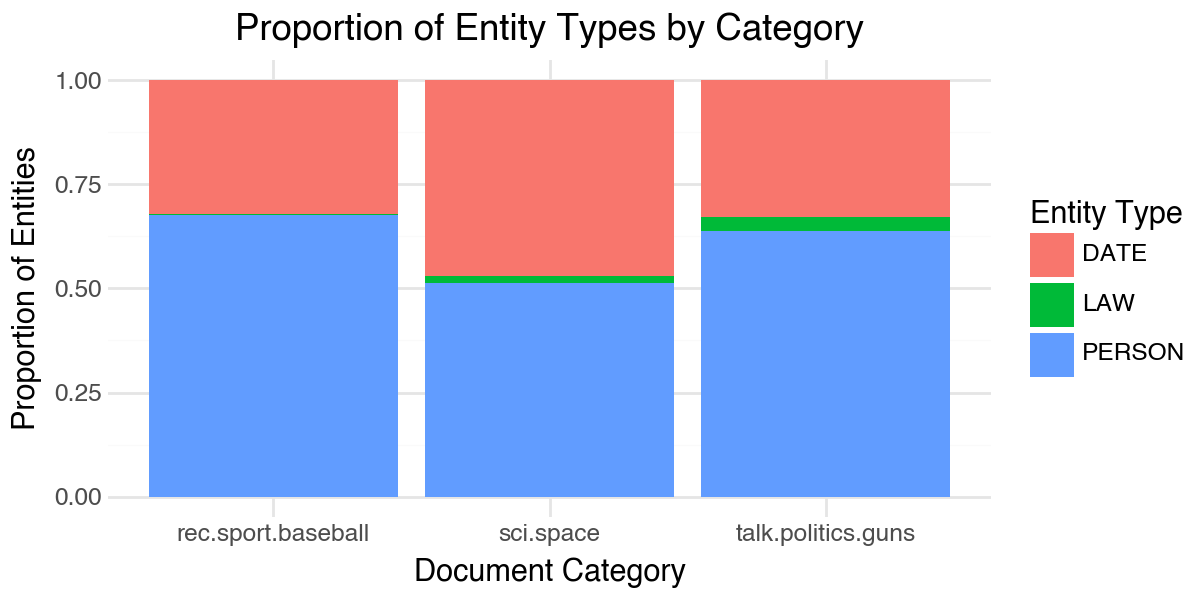

In [6]:
# Visualize entity type distributions across the corpus

# Link entities back to their source documents to get category labels
entities_df['category'] = entities_df['doc_idx'].apply(lambda idx: category_names[newsgroups.target[idx]])

# Plot proportion of discovered entity types by category
plot = (ggplot(entities_df, aes(x='category', fill='label')) +
    geom_bar(position='fill') +
    labs(title='Proportion of Entity Types by Category',
         x='Document Category',
         y='Proportion of Entities',
         fill='Entity Type') +
    theme_minimal() +
    # Set figure size
    theme(figure_size=(6, 3))
)
display(plot)

In [7]:
# Test for significance with a chi-squared test
# Is LAW significantly more common in 'talk.politics.guns' than in 'rec.sport.baseball'?
from scipy.stats import chi2_contingency

# Subset to two categories for the test
subset_df = entities_df[entities_df['category'].isin(['talk.politics.guns', 'rec.sport.baseball'])]

# Create a contingency table for LAW entities in the two categories
contingency_table = pd.crosstab(
    subset_df['category'],
    subset_df['label'] == 'LAW'
)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-squared test for LAW entity distribution between Politics and Baseball categories:")
print(f"Chi-squared: {chi2:.2f}")
if p < 0.001:
    print(f"p < 0.001")
else:
    print(f"p-value: {p:.3f}")


Chi-squared test for LAW entity distribution between Politics and Baseball categories:
Chi-squared: 37.38
p < 0.001
